# Code

## Configuration & General

### Imports

In [ ]:
!git clone https://github.com/google-research/timesfm.git
!pip install -e ./timesfm

fatal: destination path 'timesfm' already exists and is not an empty directory.
Obtaining file:///content/timesfm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for timesfm (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-0.editable-py3-none-any.whl size=7240 sha256=a398cf7cc6e23bbe00238a495c5ac3ff88333c94532572a9adcea420591fad20
  Stored in directory: /tmp/pip-ephem-wheel-cache-ybipbm7e/wheels/ac/ab/a9/bb266c6b9fb1045c9820bc505744d7d341b734de0fee7fae41
Successfully built timesfm
  Attempting uninstall: timesfm
    Found existing installation: timesfm 2.0.0
    Uninstalling timesfm-2.0.0:
      Successfully uninstalled timesfm-2.0.0


In [ ]:
from sklearn import set_config
set_config(transform_output="pandas")

import os
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from google.colab import drive

# --- CONFIGURATION & GLOBALS ---
drive.mount('content/')
plt.style.use("ggplot")

BASE_DIR = "content/MyDrive/Colab Notebooks/GP Datasets/"
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MAIN_CSV_FILE = "25_countries_main.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Drive already mounted at content/; to attempt to forcibly remount, call drive.mount("content/", force_remount=True).


### Loading data

In [ ]:
data_df = pd.read_csv(MAIN_CSV_PATH, parse_dates=['date'])

data_df.shape

(14100, 32)

## Preprocessing & Feature Engineering

### Helpers

In [ ]:
# @title
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
# @title
class FeatureEngineerMixin(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")

        X_copy = X.copy()

        X_copy['date'] = pd.to_datetime(X_copy['date'])

        X_copy['day_of_week'] = X_copy['date'].dt.dayofweek
        X_copy['quarter'] = X_copy['date'].dt.quarter

        # Add Cyclic Encoding Transformations for dates and seasons.
        X_copy['month_sin'] = np.sin(2 * np.pi * X_copy['month'] / 12)
        X_copy['month_cos'] = np.cos(2 * np.pi * X_copy['month'] / 12)
        X_copy['week_sin'] = np.sin(2 * np.pi * X_copy['week'] / 52)
        X_copy['week_cos'] = np.cos(2 * np.pi * X_copy['week'] / 52)

        # A. Temporal Lags (The "Incubation Period")
        # We look back 1 week for pollution and temprature because diseases aren't instant.
        X_copy['pm25_ugm3_lag_1w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(1)
        X_copy['pm25_ugm3_lag_2w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(2)
        X_copy['pm25_ugm3_lag_4w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(4)

        X_copy['temp_lag_1w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(1)
        X_copy['temp_lag_2w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(2)

        # B. Rolling Averages (The "Chronic Exposure")
        # B1. We calculate the average temperature of the last 4 weeks.
        X_copy['temp_2w_avg'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
        )

        # B2. Rolling standard deviation (volatility)
        X_copy['temp_2w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).std())
        )

        X_copy['temp_4w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=4, min_periods=1).std())
        )

        # C. Mathematical Transformations (Non-Linearity)
        # Temperature usually has a U-shaped effect on health (bad if too hot OR too cold)
        X_copy['temp_squared'] = X_copy['temperature_celsius'] ** 2

        # Log-Transform Target Variables
        # We do NOT scale this later.
        # X_copy['food_security_index_log'] = np.log1p(X_copy['food_security_index'])


        # D. Scientific Logic: The human body adapts to gradual change.
        # Sudden spikes (Thermal Shock) cause heart attacks and asthma attacks.
        # D1. We calculate: (Current Week Value) - (Last Week Value)
        X_copy['temp_change_rate'] = X_copy.groupby('country_code')['temperature_celsius'].diff()
        X_copy['pm25_change_rate'] = X_copy.groupby('country_code')['pm25_ugm3'].diff()
        X_copy['precip_change_rate'] = X_copy.groupby('country_code')['precipitation_mm'].diff()

        # E. Calculate Spatial Lag for Respiratory Disease
        # We take the average disease rate of the 5 neighbors (excluding the country itself)
        coords = X_copy[['latitude' , 'longitude']].values

        nbrs = NearestNeighbors(n_neighbors=5 , algorithm='ball_tree').fit(coords)
        distances , indices = nbrs.kneighbors(coords)

        neighbor_idx = indices[: , 1:] # Drop the first one (itself)

        X_copy['spatial_lag_pm25'] = X_copy['pm25_ugm3'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp'] = X_copy['temperature_celsius'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp_anomaly'] = X_copy['temp_anomaly_celsius'].values[neighbor_idx].mean(axis=1)

        # F. The "Photochemical Smog" Effect
        # Scientific Logic: High heat catalyzes chemical reactions in pollutants (like Ozone/PM2.5), making them more toxic to the lungs.
        X_copy['pm25_temp_interaction'] = X_copy['pm25_ugm3'] * X_copy['temperature_celsius']
        X_copy['temp_precip_interaction'] = X_copy['temperature_celsius'] * X_copy['precipitation_mm']
        X_copy['pm25_precip_interaction'] = X_copy['pm25_ugm3'] * X_copy['precipitation_mm']

        # G. Hemisphere Indicators
        X_copy['is_northern'] = (X_copy['latitude'] > 0).astype(int)
        X_copy['is_tropical'] = (X_copy['latitude'].abs() < 23.5).astype(int)
        X_copy['distance_to_equator'] = X_copy['latitude'].abs()


        # I. The "Vulnerability" Effect
        # Scientific Logic: High pollution is manageable if Healthcare Access is high.
        # It becomes fatal if Healthcare is low.
        # We add a small epsilon (1e-6) to avoid division by zero.

        X_copy['pollution_vulnerability'] = X_copy['pm25_ugm3'] / (X_copy['healthcare_access_index'] + 1e-6)

        X_copy = X_copy.drop(columns=['month', 'week'])
        X_copy.fillna(X_copy.mean(numeric_only=True), inplace=True)

        self.feature_names_ = X_copy.columns.tolist()

        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return self.feature_names_

In [ ]:
# @title
class CountryIQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, country_col='country_code', multiplier=1.5):
        self.country_col = country_col
        self.multiplier = multiplier

    def fit(self, X, y=None):
        self.feature_names_ = X.columns.tolist()
        self.bounds_ = {}

        for country in X[self.country_col].unique():
            mask = X[self.country_col] == country
            country_data = X.loc[mask, self.feature_names_]

            self.bounds_[country] = {}

            for col in self.feature_names_:
                if col == self.country_col: continue

                series = country_data[col].dropna()

                if len(series) < 10:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                Q1 = series.quantile(0.25)
                Q3 = series.quantile(0.75)
                IQR = Q3 - Q1

                if IQR == 0:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                lower = Q1 - self.multiplier * IQR
                upper = Q3 + self.multiplier * IQR
                self.bounds_[country][col] = (lower, upper)

        return self

    def transform(self, X):
        if not hasattr(self, 'bounds_'):
            raise ValueError("Capper has not been fitted yet. Call fit() first.")

        _X = X.copy()

        for country in _X[self.country_col].unique():
            mask = _X[self.country_col] == country

            if country not in self.bounds_:
                continue

            for col in self.feature_names_:
                if col == self.country_col: continue

                lower, upper = self.bounds_[country][col]
                _X.loc[mask, col] = _X.loc[mask, col].clip(lower=lower, upper=upper)

        return _X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return input_features




In [ ]:
# @title
class SelectiveStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_cols=None, drop_excluded=False):
        self.exclude_cols = exclude_cols or []
        self.drop_excluded = drop_excluded

    def fit(self, X, y=None):
        X = X.copy()

        self.scale_cols_ = [c for c in X.columns if c not in self.exclude_cols]

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.scale_cols_])

        self.feature_names_in_ = X.columns.tolist()
        self.feature_names_out_ = self.scale_cols_ if self.drop_excluded else self.feature_names_in_

        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy[self.scale_cols_] = X_copy[self.scale_cols_].astype("float64")
        X_copy.loc[:, self.scale_cols_] = self.scaler_.transform(X_copy[self.scale_cols_])

        if self.drop_excluded:
            X_copy = X_copy[self.scale_cols_]

        return X_copy

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

### Pipeline

In [ ]:
# @title
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Categorical features
categorical_ordinal = ['income_level']
categorical_onehot = ['region']

# Core numeric features (will be used to create engineered features)
core_numeric_features = [
    'latitude', 'longitude',
    'temperature_celsius', 'temp_anomaly_celsius',
    'pm25_ugm3', 'precipitation_mm',
    'food_security_index', 'population_millions',
    'air_quality_index', 'aqi_pm',
    'gdp_per_capita_usd', 'mental_health_index',
]

# Engineered features (created by FeatureEngineerMixin)
engineered_features = [
    # PM2.5 lags and changes
    'pm25_ugm3_lag_1w', 'pm25_ugm3_lag_2w', 'pm25_ugm3_lag_4w',
    'pm25_change_rate',
    # Temperature lags and volatility
    'temp_lag_1w', 'temp_lag_2w',
    'temp_2w_volatility', 'temp_4w_volatility', 'temp_2w_avg',
    'temp_squared', 'temp_change_rate',
    # Precipitation
    'precip_change_rate',
    # Interactions
    'pm25_temp_interaction', 'pm25_precip_interaction',
    'temp_precip_interaction', 'pollution_vulnerability'
]

# Geographic/spatial features (likely from FeatureEngineerMixin)
spatial_features = [
    'spatial_lag_pm25', 'spatial_lag_temp', 'spatial_lag_temp_anomaly',
    'is_northern', 'is_tropical', 'distance_to_equator'
]

# Environmental event indicators
event_features = ['heat_wave_days', 'drought_indicator', 'flood_indicator', 'extreme_weather_events']

# Temporal features (from FeatureEngineerMixin)
temporal_features = ['day_of_week', 'quarter', 'month_sin', 'month_cos', 'week_sin', 'week_cos']

# All numeric features that should be preprocessed
all_numeric_features = core_numeric_features + engineered_features + spatial_features + event_features + temporal_features

numeric_pipeline = Pipeline([
    ('capped', CountryIQRCapper()),
    ('knn_imputer', KNNImputer(n_neighbors=5)),
])

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal_categorical', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_ordinal),
        ('onehot_categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_onehot),
        ('preprocessed', numeric_pipeline, all_numeric_features),
    ],
    verbose_feature_names_out=False,
    remainder='passthrough'
)

pipeline = Pipeline([
    ('date_feature_engineer', FeatureEngineerMixin()),
    ('numeric_preprocessing', numeric_preprocessor),
])

pipeline

Pipeline(steps=[('date_feature_engineer', FeatureEngineerMixin()),
                ('numeric_preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_categorical',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['income_level']),
                                                 ('onehot_categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['region']),
                                                 ('...
                                                   'pm25_ugm3_lag_4w',
                                                   'pm25_change_rate',
                                                   'temp_lag_1w', 'temp_lag_2w',
                                                   'temp_2w_volatility',
                                                   'temp_4w_volatility',
                                                   'temp_2w_avg',
                                                   'temp_squared',
                                                   'temp_change_rate',
                                                   'precip_change_rate',
                                                   'pm25_temp_interaction',
                                                   'pm25_precip_interaction',
                                                   'temp_precip_interaction',
                                                   'pollution_vulnerability',
                                                   'spatial_lag_pm25',
                                                   'spatial_lag_temp', ...])],
                                   verbose_feature_names_out=False))])

## Feature Selection

In [ ]:
features = [
    'temp_squared', 'pm25_ugm3', 'heat_wave_days', 'month_sin',
    'temp_precip_interaction', 'aqi_pm', 'temp_anomaly_celsius',
    'pollution_vulnerability', 'flood_indicator', 'healthcare_access_index',
    'distance_to_equator', 'pm25_change_rate', 'pm25_ugm3_lag_1w', 'month_cos',
    'temp_change_rate', 'temperature_celsius', 'gdp_per_capita_usd',
    'quarter', 'spatial_lag_pm25', 'is_northern',
    'is_tropical', 'spatial_lag_temp', 'food_security_index',
]

# Feature groups dictionary including overlaps and derived categories
feature_groups = {
    "Air Quality": [
        "pm25_ugm3", "aqi_pm", "pm25_change_rate",
        "pm25_ugm3_lag_1w", "spatial_lag_pm25", "pollution_vulnerability"
    ],
    "Climate": [
        "temperature_celsius", "temp_squared", "temp_change_rate",
        "temp_anomaly_celsius", "temp_precip_interaction", "heat_wave_days",
        "flood_indicator", "spatial_lag_temp", "distance_to_equator",
        "is_tropical", "month_sin", "month_cos", "quarter"
    ],
    "Socioeconomic": [
        "gdp_per_capita_usd", "food_security_index",
        "pollution_vulnerability", "healthcare_access_index"
    ],
    "Healthcare": [
        "healthcare_access_index", "pollution_vulnerability", "heat_wave_days"
    ],
    "Seasonal": [
        "month_sin", "month_cos", "quarter",
        "pm25_ugm3_lag_1w", "temp_change_rate", "pm25_change_rate"
    ],
    "Geographic & Spatial": [
        "distance_to_equator", "is_northern", "is_tropical",
        "spatial_lag_pm25", "spatial_lag_temp"
    ],
    "Exposure & Risk": [
        "pollution_vulnerability", "flood_indicator", "heat_wave_days",
        "food_security_index", "healthcare_access_index"
    ]
}

targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']

## TimesFM

In [ ]:
import timesfm
from typing import Any, Sequence

# Categorical features
categorical_features = ['income_level', 'region']

# Core numeric features (will be used to create engineered features)
core_numeric_features = [
    'latitude', 'longitude',
    'temperature_celsius', 'temp_anomaly_celsius',
    'pm25_ugm3', 'precipitation_mm',
    'food_security_index', 'population_millions',
    'air_quality_index', 'aqi_pm',
    'gdp_per_capita_usd', 'mental_health_index',
]

class SehetnaTimesFMPipeline:
    def __init__(self, model: timesfm.TimesFM_2p5_200M_torch, df: pd.DataFrame, categorical_features: list[str], numeric_features: list[str]):
        self.data_df = df.copy()
        self.model = model
        self.categorical_covariates = categorical_features
        self.numeric_covariates = numeric_features
        self.results = {}
        """
        historical_y_features = y_historical | y_past
        features = covariates = works_beside_hitsorical_data = historical_x | x_past

        formulas:
            lightgbm: X[t] predicts y[t]
            sequential_models:
                1- y_past predicts y_future | y[t - seq_len : t] predicts y[t : t + horizon_len]
                    PatchTST shape/dim of data
                        - Input: [total_samples, total_rows, 5]
                        - Output: [total_samples, 6, 5]
                2- X_y_past predicts y_future | Xy[t - seq_len : t] predicts y[t : t + horizon_len] (suspended for now)
            X = covariates (temprature, precipitian), y = target
        """


    def extract_series_by_country(self, col_name: str, country_code: str) -> np.ndarray | None:
        country_data = self.data_df[self.data_df['country_code'] == country_code]

        if country_data.empty:
            return None

        series = country_data[col_name].values

        return series

    def extract_countries_series(self, col_name: str):
        countries = []
        series_list = []

        for country in self.data_df['country_code'].unique():
            s = self.extract_series_by_country(col_name, country) # np.array of country's target data
            if s is None:
                continue

            countries.append(country)
            series_list.append(s)

        if not series_list:
            raise ValueError(f"No valid series for {col_name}")

        """
        [
            [],
            [],
            ...each country's series for this target
        ]
        """


        return countries, series_list

    def split_train_test(self, series_list, test_size=0.2):
        train, test = [], []

        for s in series_list:
            split_point = int(len(s) * (1 - test_size))
            train.append(s[:split_point])
            test.append(s[split_point:])

        return train, test

    def forecast_single_target(self, target: str, horizon=12, test_size=0.2):
        print(f"Forecasting {target}")

        countries, all_inputs = self.extract_countries_series(target)

        train_inputs, test_actuals = self.split_train_test(all_inputs, test_size)

        series_len = self.data_df[target].shape[0]
        test_len = test_actuals[0].shape[0]

        if horizon > test_len:
            new_test_size = horizon / series_len
            new_horizon = test_len

            raise ValueError(f"""
Horizon ({horizon}) cannot be greater than the length of actual data ({test_len})
This breaks forecast interpretability and evaluation.

Choose ONE of the following fixes:

1) Increase test_size:
- Current test_size: {test_len / series_len:.3f}
- Minimum required test_size:
    new_test_size ≥ horizon / series_len = {new_test_size:.3f}

2) Decrease horizon:
- Maximum allowed horizon:
    new_horizon ≤ test_len = {new_horizon}

Tip:
- Increasing test_size improves evaluation stability
- Decreasing horizon improves short-term reliability
        """)

        point_forecasts, quantile_forecasts = self.model.forecast(
            inputs=train_inputs,
            horizon=horizon
        )

        metrics = self._compute_metrics(
            y_true=test_actuals,
            y_pred=point_forecasts
        )

        return {
            "countries": countries,
            "forecasts": point_forecasts,
            "quantiles": quantile_forecasts,
            "actuals": test_actuals,
            "metrics": metrics
        }


    def transform_covariates(self, covariates: list[str]) -> dict[str, Sequence[Sequence[float]]]:
        return {
            col: [group[col].values for _, group in self.data_df.groupby("country_code")]
            for col in covariates
        }

    def slice_covariates(self, covariates, split_points):
        sliced = {}

        for col, series_list in covariates.items():
            valid_series = []
            for s, sp in zip(series_list, split_points):
                if sp <= 0:
                    continue
                valid_series.append(s[:sp])

            sliced[col] = valid_series

        return sliced

    def forecast_target_with_covariates(self, target: str, test_size=0.3):
        print(f"Forecasting {target} with covariates")

        countries, all_series = self.extract_countries_series(target)

        # Split target
        train_inputs, test_actuals = self.split_train_test(all_series, test_size)

        split_points = [int(len(s) * (1 - test_size)) for s in all_series]

        # Prepare numeric covariates
        full_numeric_covs = self.transform_covariates(self.numeric_covariates)
        train_numeric_covs = self.slice_covariates(full_numeric_covs, split_points)

        model_out, xreg_out = self.model.forecast_with_covariates(train_inputs, train_numeric_covs)

        return {"countries": countries, "history": train_inputs, "actuals": test_actuals, "timesfm": model_out, "xreg": xreg_out}

    def _compute_metrics(self, y_true: list[np.ndarray], y_pred: np.ndarray) -> dict[str, float]:
        # Convert to comparable shape
        y_true_flat, y_pred_flat = [], []

        for t, p in zip(y_true, y_pred):
            min_len = min(len(t), len(p))
            y_true_flat.extend(t[:min_len])
            y_pred_flat.extend(p[:min_len])

        y_true_flat = np.array(y_true_flat)
        y_pred_flat = np.array(y_pred_flat)

        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
            'mae': mean_absolute_error(y_true_flat, y_pred_flat),
            'mape': mean_absolute_percentage_error(y_true_flat, y_pred_flat) * 100,
        }

        try:
            metrics['r2'] = r2_score(y_true_flat, y_pred_flat)
        except:
            metrics['r2'] = np.nan

        return metrics

    def forecast_all(self, targets, horizon=12) -> dict[str, dict]:
        for target in targets:
            result = self.forecast_single_target(target=target, horizon=horizon)

            if not result:
                continue

            self.results[target] = result

            # Print summary
            metrics = result['metrics']
            print(f"  RMSE: {metrics.get('rmse', np.nan):.4f}")
            print(f"  MAE:  {metrics.get('mae', np.nan):.4f}")
            print(f"  MAPE: {metrics.get('mape', np.nan):.2f}%")
            print(f"  R2:   {metrics.get('r2', np.nan):.4f}")

        return self.results

In [ ]:
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
model.compile(
    timesfm.ForecastConfig(
    max_context=512,
    max_horizon=52,
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    fix_quantile_crossing=True,
))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.


model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

In [ ]:
# Initialize pipeline
pipeline = SehetnaTimesFMPipeline(model, data_df, categorical_features, core_numeric_features)

In [ ]:
# Forecast with user-specified horizon
results = pipeline.forecast_all(targets, horizon=52)

Forecasting respiratory_disease_rate
  RMSE: 12.6029
  MAE:  10.0907
  MAPE: 16.17%
  R2:   0.3045
Forecasting cardio_mortality_rate
  RMSE: 5.6120
  MAE:  4.4915
  MAPE: 15.32%
  R2:   -0.0070
Forecasting vector_disease_risk_score
  RMSE: 7.8642
  MAE:  4.5248
  MAPE: 95959961891968000.00%
  R2:   0.7823
Forecasting waterborne_disease_incidents
  RMSE: 5.6018
  MAE:  4.2113
  MAPE: 22.32%
  R2:   0.3002
Forecasting heat_related_admissions
  RMSE: 6.1780
  MAE:  3.5662
  MAPE: 127911629795723776.00%
  R2:   0.5928


In [ ]:
result = results[targets[-1]]
forecasts = result["forecasts"]
quantiles = result["quantiles"]
actuals = result["actuals"]

actuals

(25, 108)

In [ ]:
def visualize_forecasts(results, target: str, n_countries: int = 5):
    if target not in results:
        print(f"No results for {target}")
        return

    result = results[target]
    forecasts = result["forecasts"]
    quantiles = result["quantiles"]
    actuals = result["actuals"]

    fig, axes = plt.subplots(n_countries, 1, figsize=(14, 2))
    if n_countries == 1:
        axes = [axes]

    for idx, ax in enumerate(axes[:n_countries]):
        if idx >= len(forecasts):
            break

        horizon = len(forecasts[idx])
        actual = actuals[idx][:horizon]
        forecast = forecasts[idx]
        q = quantiles[idx]   # shape: (horizon, n_quantiles)

        q_low = q[:, 0]   # e.g. 10th percentile
        q_med = q[:, 4]   # 50th percentile
        q_high = q[:, 9]  # 90th percentile

        x = np.arange(horizon)

        ax.plot(x, actual, "o-", label="Actual", linewidth=2)
        # ax.plot(x, q_med, "d-", label="Median Forecast (q50)", linewidth=2)
        ax.plot(x, forecast, "s--", label="Forecast", linewidth=2)

        ax.fill_between(
            x,
            q_low,
            q_high,
            alpha=0.25,
            label="Uncertainty Band (q10–q90)"
        )

        ax.set_title(f"{target}")
        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Value")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


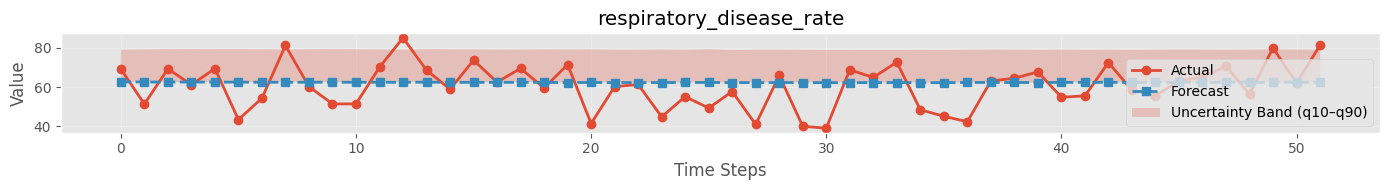

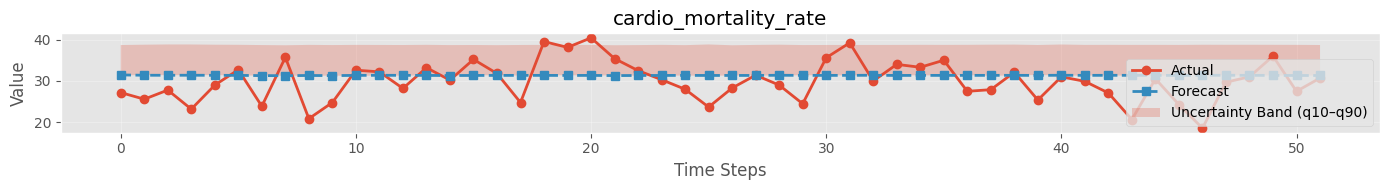

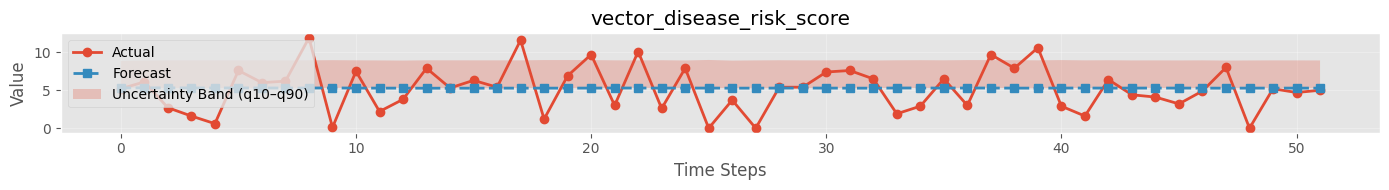

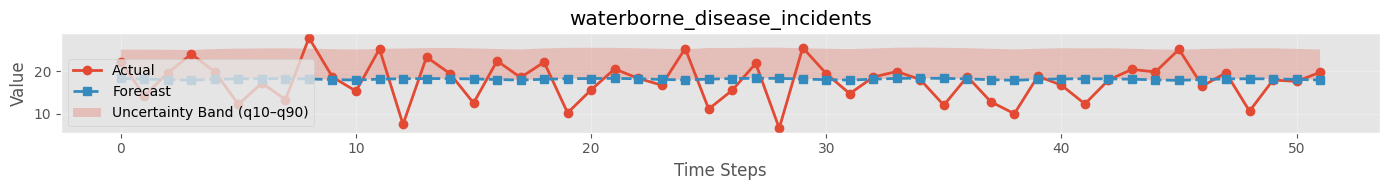

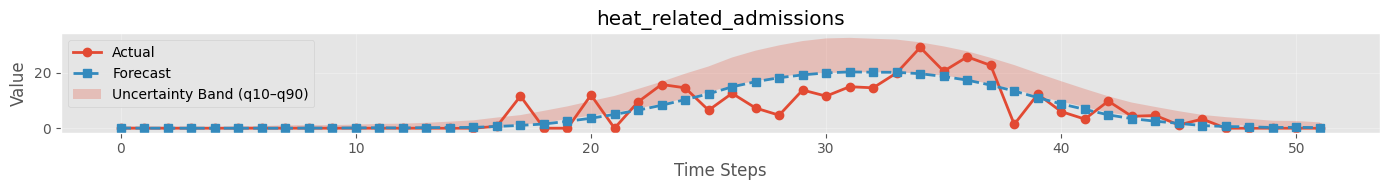

In [ ]:
# Visualize
for target in targets:
    visualize_forecasts(results, target, 1)